# Proyek Akhir: Bitcoin Price Forecasting dengan LSTM & Seq2Seq



## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

2026-03-12 21:34:29.089471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773351269.468789      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773351269.579621      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773351270.608540      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773351270.608583      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773351270.608585      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.3.3


## 2. Load Data & Eksplorasi Data Analysis (EDA)

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url, parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Rename 'Close' to 'Price' agar konsisten dengan latihan multivariate
df.rename(columns={'Close': 'Price'}, inplace=True)

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nDescribe:")
df.describe()

Shape: (53150, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 53150 entries, 2017-09-21 09:00:00.000 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Price        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8+ MB
None

Describe:


,Price,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


In [3]:
# Cek missing values dan duplikasi
print("Missing values:\n", df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

# Drop missing values jika ada
df.dropna(inplace=True)
print("\nShape after cleaning:", df.shape)

Missing values:
 Price          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64

Duplicated rows: 0

Shape after cleaning: (53150, 6)


### 2.1 Heatmap Korelasi Antar Fitur

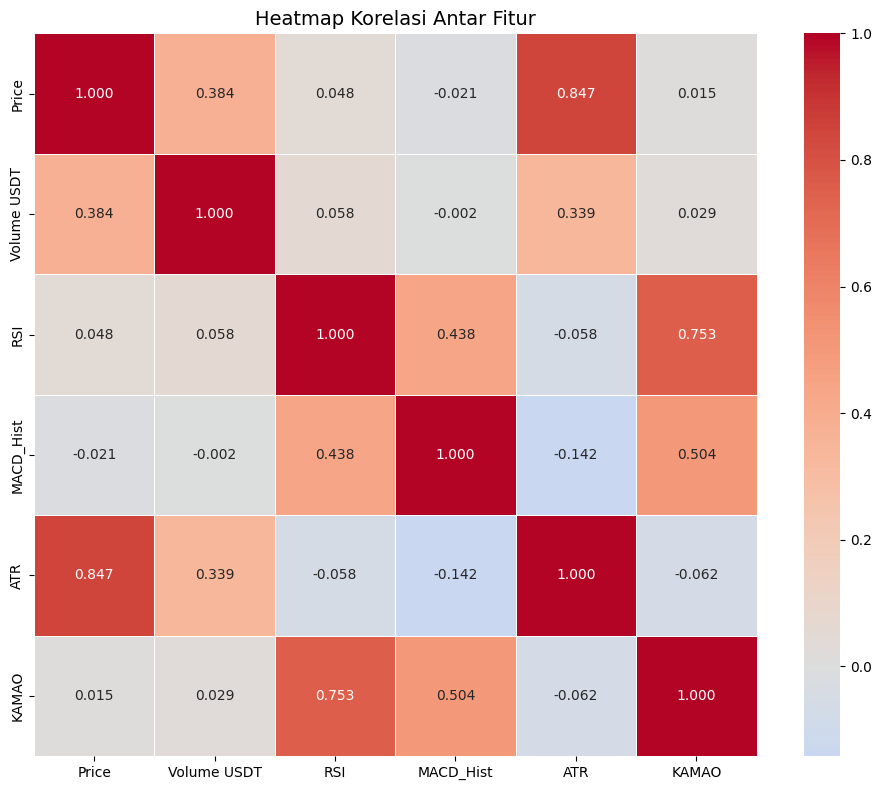


Korelasi dengan Price:
Price          1.000000
ATR            0.847282
Volume USDT    0.383990
RSI            0.047695
KAMAO          0.015203
MACD_Hist     -0.020707
Name: Price, dtype: float64


In [4]:
# Heatmap korelasi antar fitur
features_corr = ['Price', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
corr_matrix = df[features_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.3f',
    square=True,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKorelasi dengan Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

### 2.2 Analisis Dekomposisi Time Series pada Data Target (Price)

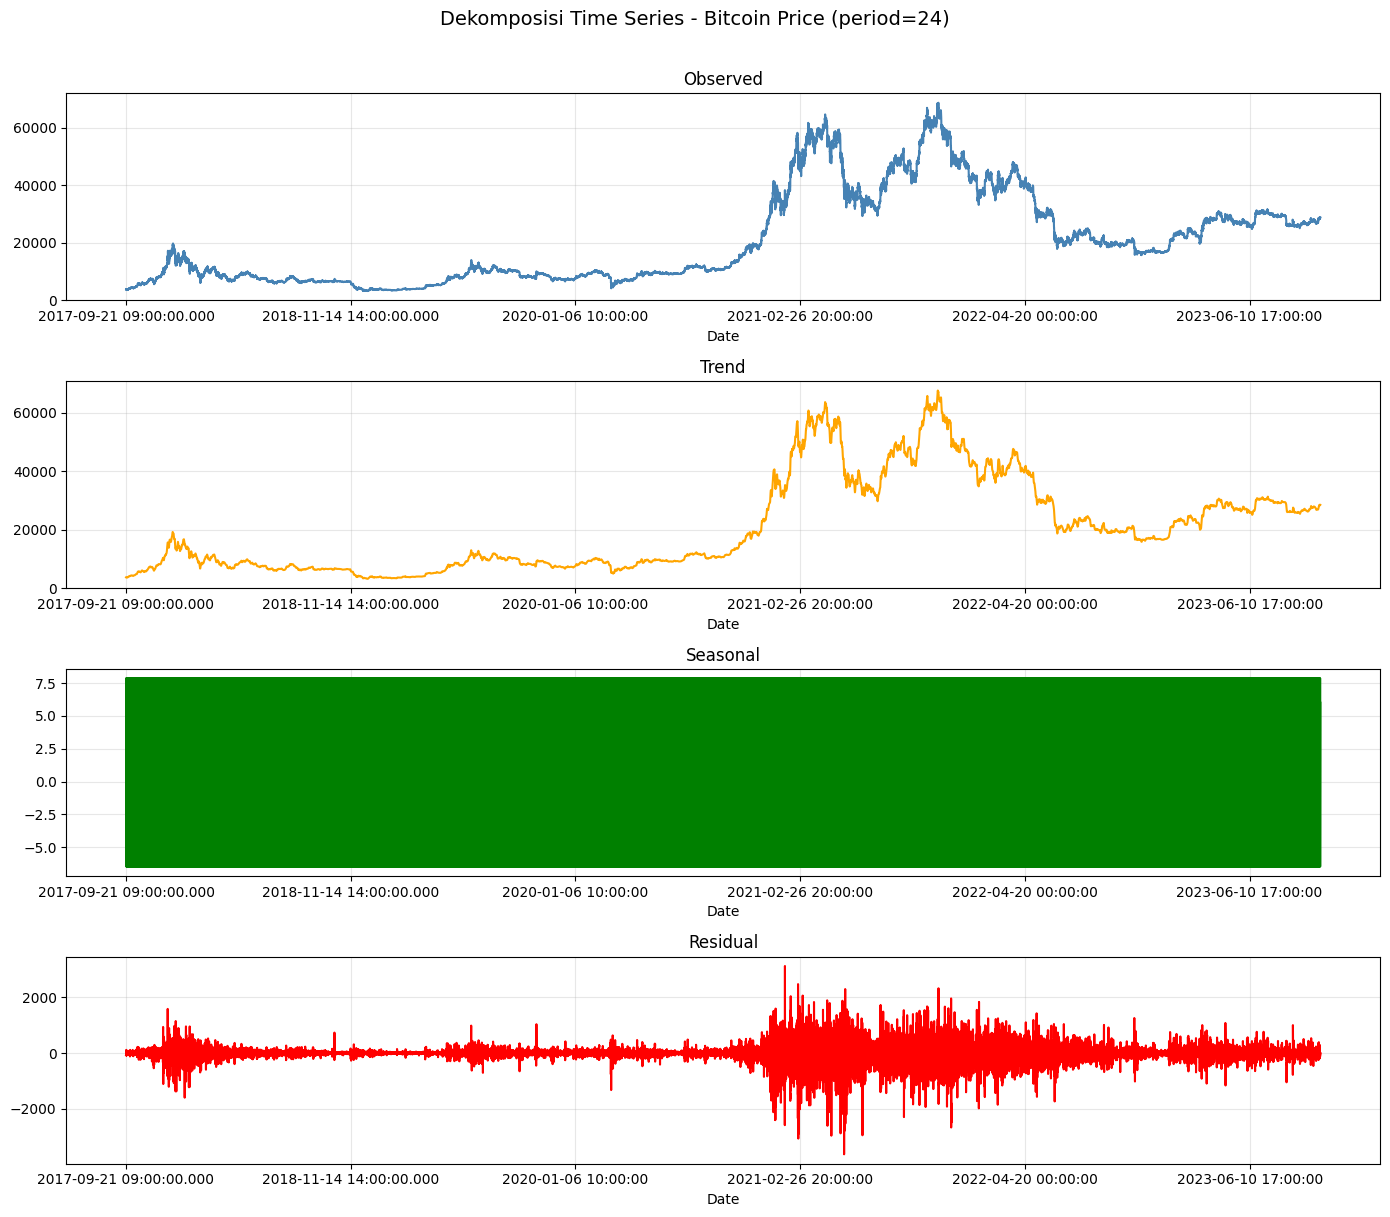

In [5]:
# Dekomposisi time series pada data target (Price)
decomposition = seasonal_decompose(df['Price'], model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
axes[0].grid(True, alpha=0.3)
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
axes[1].grid(True, alpha=0.3)
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
axes[2].grid(True, alpha=0.3)
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
axes[3].grid(True, alpha=0.3)

fig.suptitle('Dekomposisi Time Series - Bitcoin Price (period=24)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Analisis ACF & PACF

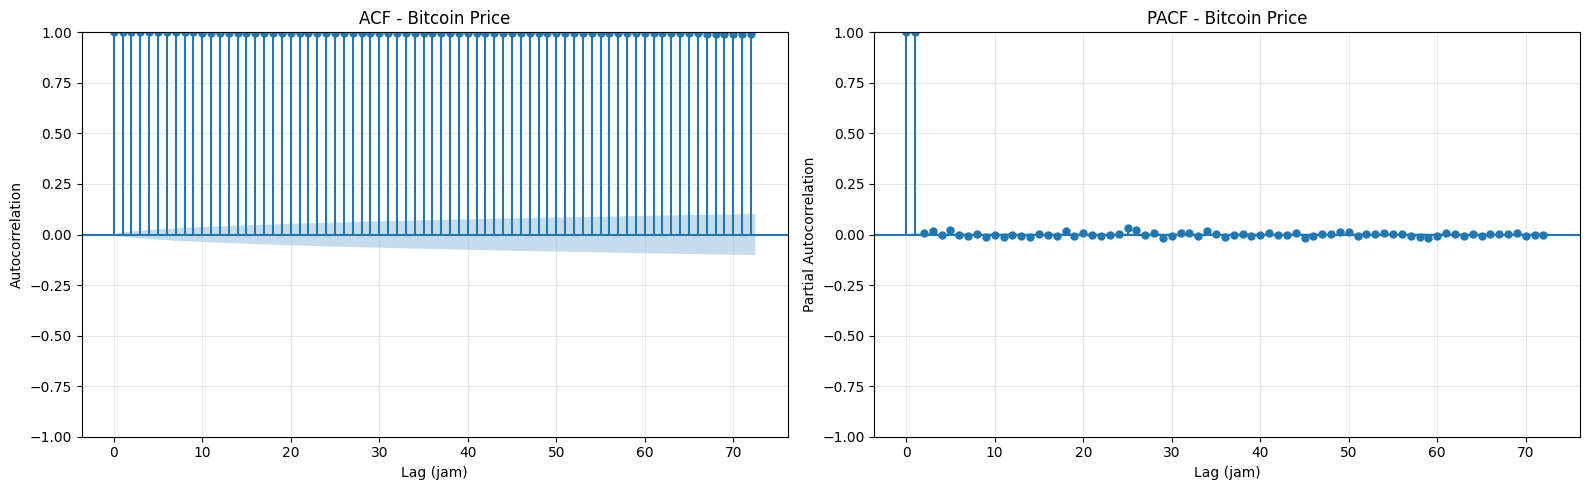

Window Size yang dipilih: 300 time steps
Forecast Horizon: 24 time steps


In [6]:
# Uji ACF dan PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['Price'].dropna(), lags=72, ax=axes[0], title='ACF - Bitcoin Price')
axes[0].set_xlabel('Lag (jam)')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True, alpha=0.3)

plot_pacf(df['Price'].dropna(), lags=72, ax=axes[1], title='PACF - Bitcoin Price', method='ywm')
axes[1].set_xlabel('Lag (jam)')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Berdasarkan ACF: autocorrelation signifikan hingga lag yang sangat panjang
# → Pilih WINDOW_SIZE = 300 untuk menangkap pola jangka panjang
print("Window Size yang dipilih: 300 time steps")
print("Forecast Horizon: 24 time steps")

## 3. Feature Engineering — Rolling Statistics



In [7]:
# Salin data asli agar tidak terganggu
data = df.copy()

# Ukuran window untuk Rolling Statistic
short_window = 7
long_window = 30

data['rolling_mean'] = data['Price'].rolling(window=short_window).mean()
data['rolling_std'] = data['Price'].rolling(window=long_window).std()

# Isi nilai NaN di awal data
data.fillna(0, inplace=True)

print("Shape after feature engineering:", data.shape)
print("\nColumns:", data.columns.tolist())
data.head(35)

Shape after feature engineering: (53150, 8)

Columns: ['Price', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'rolling_mean', 'rolling_std']


,Price,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,rolling_mean,rolling_std
Date,,,,,,,,
2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591,0.000000,0.000000
2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710,0.000000,0.000000
2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239,0.000000,0.000000
2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245,0.000000,0.000000
2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654,0.000000,0.000000
2017-09-21 14:00:00.000,3782.55,231023.998905,48.925944,-46.262423,87.587496,1.571521,0.000000,0.000000
2017-09-21 15:00:00.000,3727.44,609361.249445,48.736675,-46.299018,87.722236,0.936793,3831.595714,0.000000
2017-09-21 16:00:00.000,3670.00,210125.228741,48.540373,-46.539902,87.799402,0.280400,3804.452857,0.000000
2017-09-21 17:00:00.000,3663.82,110246.677572,48.519284,-46.792161,87.768451,0.209110,3774.787143,0.000000


## 4. Preprocessing Data — Split, Normalization, dan Pipeline tf.data.Dataset



In [8]:
# Pilih 3 fitur untuk multivariate
features_to_use = ['Price', 'rolling_mean', 'rolling_std']
df_multi = data[features_to_use]

n_data = len(df_multi)
train_split = int(n_data * 0.8)
val_split = int(n_data * 0.9)

train_data = df_multi.iloc[:train_split]
val_data = df_multi.iloc[train_split:val_split]
test_data = df_multi.iloc[val_split:]

print(f"Total samples : {n_data}")
print(f"Train         : {train_data.shape}  ({len(train_data)/n_data*100:.1f}%)")
print(f"Validation    : {val_data.shape}  ({len(val_data)/n_data*100:.1f}%)")
print(f"Test          : {test_data.shape}  ({len(test_data)/n_data*100:.1f}%)")

Total samples : 53150
Train         : (42520, 3)  (80.0%)
Validation    : (5315, 3)  (10.0%)
Test          : (5315, 3)  (10.0%)


In [9]:
# Scaler — fit HANYA pada data training untuk mencegah data leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data).astype(np.float32)
val_scaled = scaler.transform(val_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

print("Train scaled — min:", train_scaled.min(axis=0).round(4))
print("Train scaled — max:", train_scaled.max(axis=0).round(4))
print("dtype:", train_scaled.dtype)


Train scaled — min: [0. 0. 0.]
Train scaled — max: [1. 1. 1.]
dtype: float32


## 5. Multivariate Windowing & tf.data.Dataset Pipeline



In [10]:
WINDOW_SIZE = 300
HORIZON = 24
BATCH_SIZE = 32

def make_multivariate_windows(window, horizon):
    # Encoder input: SEMUA FITUR dari masa lalu
    encoder_input = window[:-horizon]

    # Decoder target: HANYA kolom Price (indeks ke-0)
    decoder_target = window[-horizon:, 0:1]
    start_token = encoder_input[-1:, 0:1]

    # Decoder input: start token + shifted target (tanpa nilai terakhir)
    decoder_input = tf.concat([start_token, decoder_target[:-1]], axis=0)

    return (encoder_input, decoder_input), decoder_target


def create_multivariate_dataset(series, window_size, horizon, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + horizon, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + horizon))
    ds = ds.map(lambda w: make_multivariate_windows(w, horizon))

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds_multi = create_multivariate_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
val_ds_multi = create_multivariate_dataset(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
test_ds_multi = create_multivariate_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

# Verifikasi bentuk batch
for (enc_in, dec_in), dec_target in train_ds_multi.take(1):
    print(f"Encoder input shape  : {enc_in.shape}")
    print(f"Decoder input shape  : {dec_in.shape}")
    print(f"Decoder target shape : {dec_target.shape}")

I0000 00:00:1773351311.898889      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773351311.904816      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Encoder input shape  : (32, 300, 3)
Decoder input shape  : (32, 24, 1)
Decoder target shape : (32, 24, 1)


## 6. Custom Layers



In [11]:
# =====================================================================
# CUSTOM DENSE LAYER — Membuat ulang Dense dari nol
# =====================================================================
class CustomDense(tf.keras.layers.Layer):
    """Implementasi Dense layer dari nol dengan bobot W dan bias b."""

    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='kernel'
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )
        super().build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation)
        })
        return config


# =====================================================================
# CUSTOM DROPOUT LAYER — Membuat ulang Dropout dari nol
# =====================================================================
class CustomDropout(tf.keras.layers.Layer):
    """Implementasi Dropout dari nol menggunakan Bernoulli mask."""

    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training and self.rate > 0.0:
            mask = tf.random.uniform(tf.shape(inputs)) >= self.rate
            return inputs * tf.cast(mask, inputs.dtype) / (1.0 - self.rate)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config


# =====================================================================
# CUSTOM LEAKY RELU — Membuat ulang aktivasi LeakyReLU dari nol
# =====================================================================
class CustomLeakyReLU(tf.keras.layers.Layer):
    """Implementasi LeakyReLU dari nol: f(x) = x jika x>0, alpha*x jika x<=0."""

    def __init__(self, alpha=0.01, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha

    def call(self, inputs):
        return tf.where(inputs >= 0, inputs, self.alpha * inputs)

    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha})
        return config


# =====================================================================
# CUSTOM MULTI-HEAD ATTENTION — Membuat ulang MHA dari nol
# =====================================================================
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    """
    Implementasi Multi-Head Attention dari nol.
    Arsitektur: Q/K/V projection → split heads → scaled dot-product attention
    → concat heads → output projection.
    """

    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, "d_model harus habis dibagi num_heads"
        self.d_model   = d_model
        self.num_heads = num_heads
        self.depth     = d_model // num_heads

    def build(self, input_shape):
        self.wq = self.add_weight(shape=(self.d_model, self.d_model),
                                  initializer='glorot_uniform', trainable=True, name='wq')
        self.wk = self.add_weight(shape=(self.d_model, self.d_model),
                                  initializer='glorot_uniform', trainable=True, name='wk')
        self.wv = self.add_weight(shape=(self.d_model, self.d_model),
                                  initializer='glorot_uniform', trainable=True, name='wv')
        self.wo = self.add_weight(shape=(self.d_model, self.d_model),
                                  initializer='glorot_uniform', trainable=True, name='wo')
        super().build(input_shape)

    def _split_heads(self, x, batch_size):
        """Reshape (batch, seq, d_model) → (batch, heads, seq, depth)."""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _scaled_dot_product_attention(self, q, k, v):
        """Attention(Q,K,V) = softmax(QK^T / sqrt(dk)) * V."""
        logits = tf.matmul(q, k, transpose_b=True)
        dk     = tf.cast(tf.shape(k)[-1], tf.float32)
        logits = logits / tf.math.sqrt(dk)
        weights = tf.nn.softmax(logits, axis=-1)
        return tf.matmul(weights, v)

    def call(self, query, key, value):
        batch_size = tf.shape(query)[0]

        q = tf.matmul(query, self.wq)
        k = tf.matmul(key,   self.wk)
        v = tf.matmul(value, self.wv)

        q = self._split_heads(q, batch_size)
        k = self._split_heads(k, batch_size)
        v = self._split_heads(v, batch_size)

        attn_out = self._scaled_dot_product_attention(q, k, v)

        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])
        attn_out = tf.reshape(attn_out, (batch_size, -1, self.d_model))

        return tf.matmul(attn_out, self.wo)

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads})
        return config


print("Custom layers berhasil dibuat:")
print("  • CustomDense")
print("  • CustomDropout")
print("  • CustomLeakyReLU")
print("  • CustomMultiHeadAttention")

Custom layers berhasil dibuat:
  • CustomDense
  • CustomDropout
  • CustomLeakyReLU
  • CustomMultiHeadAttention


## 7. Model 1 — Baseline LSTM dengan Custom Multi-Head Attention (Functional API)



In [12]:
N_FEATURES = 3   # Price, rolling_mean, rolling_std
D_MODEL    = 64
NUM_HEADS  = 4
LSTM_UNITS = 64


def build_baseline_lstm_model(window_size, n_features, forecast_horizon,
                               d_model=64, num_heads=4):
    """Membangun Baseline LSTM dengan Custom Multi-Head Attention (Functional API)."""
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')

    # --- Encoder LSTM ---
    x = tf.keras.layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = CustomDropout(rate=0.2, name='dropout_1')(x)
    x = tf.keras.layers.LSTM(d_model, return_sequences=True, name='lstm_2')(x)
    x = CustomDropout(rate=0.2, name='dropout_2')(x)

    # --- Custom Multi-Head Attention (self-attention) ---
    attn = CustomMultiHeadAttention(d_model=d_model, num_heads=num_heads,
                                    name='custom_mha')(x, x, x)

    # --- Residual connection + LayerNorm ---
    x = tf.keras.layers.Add(name='residual')([x, attn])
    x = tf.keras.layers.LayerNormalization(name='layer_norm')(x)

    # --- Aggregation ---
    x = tf.keras.layers.GlobalAveragePooling1D(name='gap')(x)

    # --- Output head ---
    x = CustomDense(128, name='dense_1')(x)
    x = CustomLeakyReLU(alpha=0.01, name='leaky_relu')(x)
    x = CustomDropout(rate=0.2, name='dropout_3')(x)
    outputs = CustomDense(forecast_horizon, name='dense_output')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name='baseline_lstm')


# Buat dataset khusus baseline (tanpa encoder-decoder split)
def create_baseline_windows(window, horizon):
    x = window[:-horizon]
    y = window[-horizon:, 0]   # Hanya Price
    return x, y

def create_baseline_dataset(series, window_size, horizon, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + horizon, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + horizon))
    ds = ds.map(lambda w: create_baseline_windows(w, horizon))
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds_baseline = create_baseline_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
val_ds_baseline = create_baseline_dataset(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
test_ds_baseline = create_baseline_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

baseline_lstm_model = build_baseline_lstm_model(
    WINDOW_SIZE, N_FEATURES, HORIZON, D_MODEL, NUM_HEADS
)
baseline_lstm_model.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 300, 3)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 300, 128)  │     67,584 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1           │ (None, 300, 128)  │          0 │ lstm_1[0][0]      │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 300, 64)   │     49,408 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2           │ (None, 300, 64)   │          0 │ lstm_2[0][0]      │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_mha          │ (None, None, 64)  │     16,384 │ dropout_2[0][0],  │
│ (CustomMultiHeadAt… │                   │            │ dropout_2[0][0],  │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, None, 64)  │          0 │ dropout_2[0][0],  │
│                     │                   │            │ custom_mha[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, None, 64)  │        128 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 64)        │          0 │ layer_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1             │ (None, 128)       │      8,320 │ gap[0][0]         │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_relu          │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (CustomLeakyReLU)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3           │ (None, 128)       │          0 │ leaky_relu[0][0]  │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_output        │ (None, 24)        │      3,096 │ dropout_3[0][0]   │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 144,920 (566.09 KB)

 Trainable params: 144,920 (566.09 KB)

 Non-trainable params: 0 (0.00 B)

### 7.1 Training Baseline LSTM dengan `model.fit()`

Epoch 1/10


I0000 00:00:1773351317.892933      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


1319/1319 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - loss: 0.0239 - val_loss: 0.0355
Epoch 2/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 0.0390 - val_loss: 0.0360
Epoch 3/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 0.0382 - val_loss: 0.0444
Epoch 4/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - loss: 0.0758 - val_loss: 0.0397
Epoch 5/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 0.0437 - val_loss: 0.0388
Epoch 6/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 0.0439 - val_loss: 0.0371
Epoch 7/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - loss: 0.0463 - val_loss: 0.0375
Epoch 8/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 0.0414 - val_loss: 0.0364
Epoch 9/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - loss: 0.0444 - val_loss: 0.0360
Epoch 10/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 0.0426 - val_loss: 0.0362


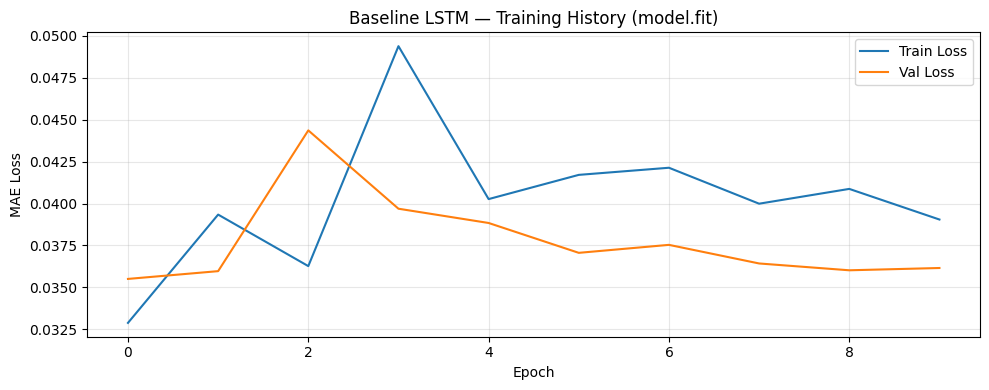

✓ Model baseline LSTM disimpan: model_baseline_lstm_multivariate.keras


In [13]:
# Compile dan latih baseline model dengan model.fit()
baseline_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae'
)

history_baseline_fit = baseline_lstm_model.fit(
    train_ds_baseline,
    validation_data=val_ds_baseline,
    epochs=10,
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history_baseline_fit.history['loss'],     label='Train Loss')
plt.plot(history_baseline_fit.history['val_loss'], label='Val Loss')
plt.title('Baseline LSTM — Training History (model.fit)')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Simpan baseline model
baseline_lstm_model.save('model_baseline_lstm_multivariate.keras')
print("✓ Model baseline LSTM disimpan: model_baseline_lstm_multivariate.keras")

## 8. Model 2 — Seq2Seq LSTM Multivariate dengan Attention (Model Subclassing)



In [14]:
class Seq2SeqMultivariate(tf.keras.Model):
    """
    Seq2Seq LSTM Multivariate dengan Teacher Forcing dan Custom Multi-Head Attention.
    - Encoder menerima 3 fitur (Price, rolling_mean, rolling_std)
    - Decoder memprediksi hanya Price (many-to-one)
    - Cross-attention dari decoder ke encoder output
    """

    def __init__(self, n_features, d_model, num_heads, forecast_horizon, **kwargs):
        super().__init__(**kwargs)
        self.forecast_horizon = forecast_horizon
        self.d_model          = d_model
        self.n_features       = n_features
        self._num_heads       = num_heads

        # ---- Encoder ----
        self.enc_lstm_1   = tf.keras.layers.LSTM(128, return_sequences=True, name='enc_lstm_1')
        self.enc_drop_1   = CustomDropout(rate=0.2, name='enc_dropout_1')
        self.enc_lstm_2   = tf.keras.layers.LSTM(d_model, return_sequences=True,
                                                  return_state=True, name='enc_lstm_2')
        self.enc_attn     = CustomMultiHeadAttention(d_model=d_model, num_heads=num_heads,
                                                     name='enc_mha')
        self.enc_norm     = tf.keras.layers.LayerNormalization(name='enc_norm')

        # ---- Decoder ----
        self.dec_input_proj = CustomDense(d_model, name='dec_input_proj')
        self.dec_lstm       = tf.keras.layers.LSTM(d_model, return_sequences=True,
                                                    return_state=True, name='dec_lstm')
        self.dec_attn       = CustomMultiHeadAttention(d_model=d_model, num_heads=num_heads,
                                                       name='dec_mha')
        self.dec_norm       = tf.keras.layers.LayerNormalization(name='dec_norm')
        self.dec_drop       = CustomDropout(rate=0.5, name='dec_dropout')
        self.dec_out_dense  = CustomDense(1, name='dec_output_dense')
        self.dec_activation = CustomLeakyReLU(alpha=0.01, name='dec_activation')

    def call(self, inputs, training=None, teacher_forcing_targets=None):
        encoder_input = inputs[0]   # (batch, window_size, 3)
        decoder_input_seq = inputs[1]  # (batch, horizon, 1) — untuk teacher forcing via dataset

        # ---- Encoder pass ----
        enc = self.enc_lstm_1(encoder_input, training=training)
        enc = self.enc_drop_1(enc, training=training)
        enc_out, state_h, state_c = self.enc_lstm_2(enc, training=training)

        # Encoder self-attention + residual
        enc_attn = self.enc_attn(enc_out, enc_out, enc_out)
        enc_out  = self.enc_norm(enc_out + enc_attn)

        # ---- Decoder pass — step by step ----
        decoder_states = [state_h, state_c]
        predictions    = []

        # Initial decoder token: last Price value dari encoder input
        dec_token = encoder_input[:, -1, 0:1]   # (batch, 1)

        for t in range(self.forecast_horizon):
            # (batch, 1) → (batch, 1, 1) → project to d_model
            dec_in = tf.expand_dims(dec_token, axis=1)  # (batch, 1, 1)
            dec_in = self.dec_input_proj(dec_in)         # (batch, 1, d_model)

            # Decoder LSTM step
            dec_out, state_h, state_c = self.dec_lstm(
                dec_in, initial_state=decoder_states, training=training
            )
            decoder_states = [state_h, state_c]

            # Cross-attention: decoder queries encoder memory
            cross = self.dec_attn(dec_out, enc_out, enc_out)
            dec_out = self.dec_norm(dec_out + cross)
            dec_out = self.dec_drop(dec_out, training=training)

            # Output prediction for this step
            pred = self.dec_out_dense(dec_out[:, -1, :])   # (batch, 1)
            predictions.append(pred)

            # Teacher forcing: use ground truth during training
            if training and teacher_forcing_targets is not None:
                dec_token = teacher_forcing_targets[:, t:t+1, 0]  # (batch, 1)
            else:
                dec_token = pred   # Autoregressive

        # Stack predictions: (batch, horizon, 1)
        return tf.stack(predictions, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_features':       self.n_features,
            'd_model':          self.d_model,
            'num_heads':        self._num_heads,
            'forecast_horizon': self.forecast_horizon,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


# Build Seq2Seq model
seq2seq_model = Seq2SeqMultivariate(
    n_features       = N_FEATURES,
    d_model          = D_MODEL,
    num_heads        = NUM_HEADS,
    forecast_horizon = HORIZON,
    name             = 'seq2seq_multivariate'
)

# Trigger .build() dengan dummy forward pass
dummy_enc = tf.random.normal((1, WINDOW_SIZE, N_FEATURES))
dummy_dec = tf.random.normal((1, HORIZON, 1))
_ = seq2seq_model([dummy_enc, dummy_dec], training=False)
seq2seq_model.summary()

Model: "seq2seq_multivariate"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_lstm_1 (LSTM)               │ (1, 300, 128)          │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dropout_1 (CustomDropout)   │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_2 (LSTM)               │ ((1, 300, 64), (1,     │        49,408 │
│                                 │ 64), (1, 64))          │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_mha                         │ ?                      │        16,384 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_norm (LayerNormalization)   │ (1, 300, 64)           │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_input_proj (CustomDense)    │ ?                      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ ((1, 1, 64), (1, 64),  │        33,024 │
│                                 │ (1, 64))               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_mha                         │ ?                      │        16,384 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_norm (LayerNormalization)   │ (1, 1, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dropout (CustomDropout)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output_dense (CustomDense)  │ ?                      │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_activation                  │ ?                      │   0 (unbuilt) │
│ (CustomLeakyReLU)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,233 (715.75 KB)

 Trainable params: 183,233 (715.75 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Model 3 — Seq2Seq Multivariate dengan Attention (Functional API)



In [15]:
# ========== Encoder ==========
encoder_input = tf.keras.layers.Input(shape=(WINDOW_SIZE, 3), name="encoder_input")
encoder_lstm = tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True,
                                     name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_input)
encoder_states = [state_h, state_c]

# ========== Decoder ==========
decoder_input = tf.keras.layers.Input(shape=(HORIZON, 1), name="decoder_input")
decoder_lstm = tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True,
                                     name="decoder_lstm")
decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(decoder_input,
                                                          initial_state=encoder_states)
decoder_dropout = tf.keras.layers.Dropout(0.5, name="decoder_dropout")(decoder_outputs)

# ========== Multi-Head Attention ==========
attention_layer = tf.keras.layers.MultiHeadAttention(
    num_heads=4, key_dim=LSTM_UNITS, name="multi_head_attention"
)
context_vector = attention_layer(
    query=decoder_dropout, value=encoder_outputs, key=encoder_outputs
)
vector_dropout = tf.keras.layers.Dropout(0.5, name="vector_dropout")(context_vector)

# ========== Concatenate & Output ==========
concat_layer = tf.keras.layers.Concatenate(axis=-1, name="concatenate_layer")
decoder_combined_output = concat_layer([decoder_dropout, vector_dropout])

output_layer = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Dense(1), name="output"
)
output = output_layer(decoder_combined_output)

# ========== Assemble Model ==========
model_attention = tf.keras.models.Model(
    inputs=[encoder_input, decoder_input], outputs=output
)
model_attention.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 300, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 300, 64), │     17,408 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 64),  │     16,896 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 24, 64)    │          0 │ decoder_lstm[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     66,368 │ encoder_lstm[0][… │
│ (MultiHeadAttentio… │                   │            │ decoder_dropout[… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vector_dropout      │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_layer   │ (None, 24, 128)   │          0 │ decoder_dropout[… │
│ (Concatenate)       │                   │            │ vector_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 24, 1)     │        129 │ concatenate_laye… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,801 (393.75 KB)

 Trainable params: 100,801 (393.75 KB)

 Non-trainable params: 0 (0.00 B)

### 9.1 Compile & Train Seq2Seq Attention (Functional API) dengan `model.fit()`

Epoch 1/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - loss: 4.5544e-04 - mae: 0.0131 - val_loss: 0.0025 - val_mae: 0.0421 - learning_rate: 0.0010
Epoch 2/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - loss: 0.0018 - mae: 0.0237 - val_loss: 0.0026 - val_mae: 0.0429 - learning_rate: 0.0010
Epoch 3/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - loss: 0.0023 - mae: 0.0277 - val_loss: 0.0030 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 4/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - loss: 0.0029 - mae: 0.0313 - val_loss: 0.0020 - val_mae: 0.0370 - learning_rate: 0.0010
Epoch 5/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - loss: 0.0028 - mae: 0.0312 - val_loss: 0.0026 - val_mae: 0.0429 - learning_rate: 0.0010
Epoch 6/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - loss: 0.0027 - mae: 0.0311 - val_loss: 0.0017 - val_mae: 0.0348 - learning_rate: 0.0010
Epoch 7/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - loss: 0.0021 - mae: 0.0275 - val_loss: 0.0011 - val_mae: 0.027

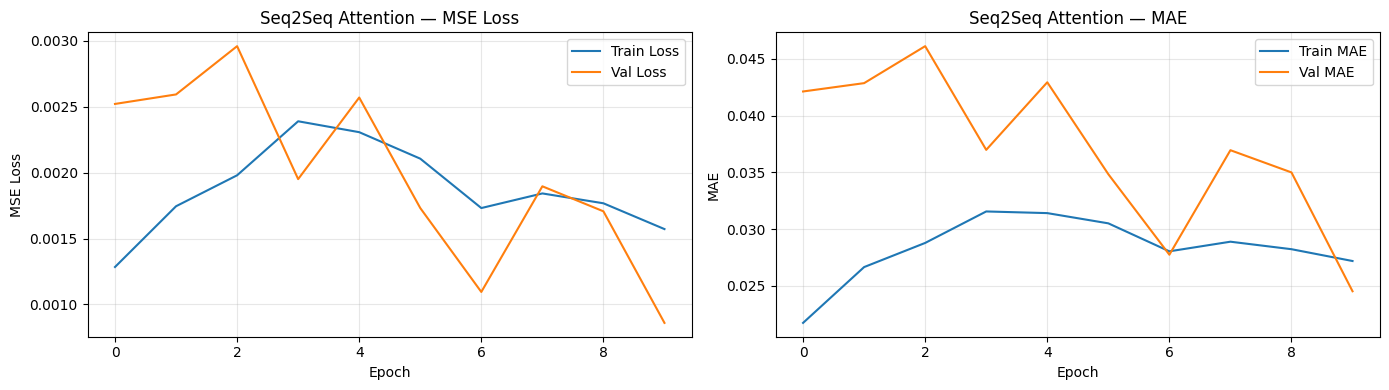

✓ Model Seq2Seq Attention disimpan: model_attention_multivariate.keras


In [16]:
# Compile model Seq2Seq Attention (Functional API)
model_attention.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# Callbacks
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', patience=5, factor=0.5, min_lr=1e-7
)

# Training
history_attention = model_attention.fit(
    train_ds_multi,
    validation_data=val_ds_multi,
    epochs=10,
    callbacks=[es_callback, lr_callback],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_attention.history['loss'],     label='Train Loss')
axes[0].plot(history_attention.history['val_loss'], label='Val Loss')
axes[0].set_title('Seq2Seq Attention — MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_attention.history['mae'],     label='Train MAE')
axes[1].plot(history_attention.history['val_mae'], label='Val MAE')
axes[1].set_title('Seq2Seq Attention — MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simpan model
model_attention.save('model_attention_multivariate.keras')
print("✓ Model Seq2Seq Attention disimpan: model_attention_multivariate.keras")

## 10. Custom Loss Functions

1. **`custom_mae_loss`** — Implementasi MAE dari nol
2. **`weighted_horizon_mae_loss`** — MAE dengan bobot meningkat per horizon step

In [17]:
# =====================================================================
# CUSTOM MAE LOSS — Implementasi dari nol
# =====================================================================
def custom_mae_loss(y_true, y_pred):
    """Custom MAE Loss: mean(|y_true - y_pred|)."""
    return tf.reduce_mean(tf.abs(y_true - y_pred))


# =====================================================================
# WEIGHTED HORIZON MAE LOSS — MAE dengan bobot meningkat per horizon step
# =====================================================================
def weighted_horizon_mae_loss(y_true, y_pred):
    """
    Custom Weighted MAE Loss.
    Bobot step ke-t: w_t = 1.0 + 0.2 * (t-1)
    Sehingga error pada step yang lebih jauh diberi penalti lebih besar.
    """
    horizon  = tf.shape(y_true)[1]
    weights  = 1.0 + 0.2 * tf.cast(tf.range(horizon), tf.float32)
    weights  = tf.reshape(weights, (1, -1, 1))   # (1, horizon, 1) untuk broadcast
    abs_err  = tf.abs(y_true - y_pred)
    w_err    = abs_err * weights
    return tf.reduce_mean(w_err)


# --- Sanity check ---
y_t = tf.random.normal((4, HORIZON, 1))
y_p = tf.random.normal((4, HORIZON, 1))
print(f"Custom MAE Loss           : {custom_mae_loss(y_t, y_p).numpy():.4f}")
print(f"Weighted Horizon MAE Loss : {weighted_horizon_mae_loss(y_t, y_p).numpy():.4f}")
print("\nBobot untuk tiap step:")
weights_demo = [1.0 + 0.2 * t for t in range(HORIZON)]
for i, w in enumerate(weights_demo):
    print(f"  Step {i+1}: w={w:.1f}")

Custom MAE Loss           : 1.0174
Weighted Horizon MAE Loss : 3.3479

Bobot untuk tiap step:
  Step 1: w=1.0
  Step 2: w=1.2
  Step 3: w=1.4
  Step 4: w=1.6
  Step 5: w=1.8
  Step 6: w=2.0
  Step 7: w=2.2
  Step 8: w=2.4
  Step 9: w=2.6
  Step 10: w=2.8
  Step 11: w=3.0
  Step 12: w=3.2
  Step 13: w=3.4
  Step 14: w=3.6
  Step 15: w=3.8
  Step 16: w=4.0
  Step 17: w=4.2
  Step 18: w=4.4
  Step 19: w=4.6
  Step 20: w=4.8
  Step 21: w=5.0
  Step 22: w=5.2
  Step 23: w=5.4
  Step 24: w=5.6


## 11. Custom Callbacks



In [18]:
# =====================================================================
# CUSTOM EARLY STOPPING — Implementasi dari nol
# =====================================================================
class CustomEarlyStopping:
    """
    Custom Early Stopping callback.
    Menghentikan training jika val_loss tidak membaik selama `patience` epoch.
    """

    def __init__(self, patience=10, min_delta=1e-5, restore_best_weights=True):
        self.patience             = patience
        self.min_delta            = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss            = float('inf')
        self.counter              = 0
        self.best_weights         = None
        self.stopped              = False

    def check(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            if self.restore_best_weights:
                self.best_weights = model.get_weights()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True
                if self.restore_best_weights and self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print(f"\n  [EarlyStopping] Dihentikan. Weights dipulihkan "
                          f"(best val_loss: {self.best_loss:.6f})")
                else:
                    print(f"\n  [EarlyStopping] Dihentikan "
                          f"(best val_loss: {self.best_loss:.6f})")
        return self.stopped


# =====================================================================
# CUSTOM REDUCE LR ON PLATEAU — Implementasi dari nol
# =====================================================================
class CustomReduceLROnPlateau:
    """
    Custom ReduceLR callback.
    Mengurangi learning rate jika val_loss tidak membaik selama `patience` epoch.
    """

    def __init__(self, optimizer, patience=5, factor=0.5, min_lr=1e-7):
        self.optimizer  = optimizer
        self.patience   = patience
        self.factor     = factor
        self.min_lr     = min_lr
        self.best_loss  = float('inf')
        self.counter    = 0

    def check(self, val_loss):
        if val_loss < self.best_loss - 1e-6:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                old_lr = float(self.optimizer.learning_rate.numpy())
                new_lr = max(old_lr * self.factor, self.min_lr)
                if new_lr < old_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    print(f"  [ReduceLR] lr: {old_lr:.2e} → {new_lr:.2e}")
                self.counter = 0

print("✓ Custom Callbacks berhasil dibuat: CustomEarlyStopping, CustomReduceLROnPlateau")

✓ Custom Callbacks berhasil dibuat: CustomEarlyStopping, CustomReduceLROnPlateau


## 12. Custom Training Loop dengan `tf.GradientTape`



In [19]:
def custom_training_loop_seq2seq(model, train_dataset, val_dataset, epochs,
                                 loss_fn, optimizer, early_stopping, reduce_lr):
    """
    Custom Training Loop untuk Seq2Seq Multivariate menggunakan tf.GradientTape.
    Dataset format: ((encoder_input, decoder_input), decoder_target)
    Teacher Forcing: decoder_target diberikan saat training.
    """
    history = {'loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # -------- Training --------
        train_losses = []
        for (enc_in, dec_in), dec_target in train_dataset:
            with tf.GradientTape() as tape:
                y_pred = model([enc_in, dec_in], training=True,
                               teacher_forcing_targets=dec_target)
                loss = loss_fn(dec_target, y_pred)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            train_losses.append(loss.numpy())

        avg_train = np.mean(train_losses)

        # -------- Validation --------
        val_losses = []
        for (enc_in, dec_in), dec_target in val_dataset:
            y_pred = model([enc_in, dec_in], training=False)
            val_losses.append(loss_fn(dec_target, y_pred).numpy())

        avg_val = np.mean(val_losses)

        history['loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        current_lr = float(optimizer.learning_rate.numpy())
        print(f"Epoch {epoch+1:3d}/{epochs} "
              f"— loss: {avg_train:.6f} "
              f"— val_loss: {avg_val:.6f} "
              f"— lr: {current_lr:.2e}")

        # Callbacks
        reduce_lr.check(avg_val)
        if early_stopping.check(avg_val, model):
            print(f"  Training dihentikan pada epoch {epoch+1}.")
            break

    return history


def custom_training_loop_baseline(model, train_dataset, val_dataset, epochs,
                                   loss_fn, optimizer, early_stopping, reduce_lr):
    """
    Custom Training Loop untuk Baseline LSTM menggunakan tf.GradientTape.
    Dataset format: (x, y) — direct multi-step prediction.
    """
    history = {'loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # -------- Training --------
        train_losses = []
        for x_batch, y_batch in train_dataset:
            with tf.GradientTape() as tape:
                y_pred = model(x_batch, training=True)
                loss = loss_fn(y_batch, y_pred)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            train_losses.append(loss.numpy())

        avg_train = np.mean(train_losses)

        # -------- Validation --------
        val_losses = []
        for x_batch, y_batch in val_dataset:
            y_pred = model(x_batch, training=False)
            val_losses.append(loss_fn(y_batch, y_pred).numpy())

        avg_val = np.mean(val_losses)

        history['loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        current_lr = float(optimizer.learning_rate.numpy())
        print(f"Epoch {epoch+1:3d}/{epochs} "
              f"— loss: {avg_train:.6f} "
              f"— val_loss: {avg_val:.6f} "
              f"— lr: {current_lr:.2e}")

        # Callbacks
        reduce_lr.check(avg_val)
        if early_stopping.check(avg_val, model):
            print(f"  Training dihentikan pada epoch {epoch+1}.")
            break

    return history

print("✓ Custom training loops berhasil didefinisikan")

✓ Custom training loops berhasil didefinisikan


### 12.1 Custom Training — Baseline LSTM

In [20]:
# Custom loss baseline: y shape = (batch, horizon) — tanpa dimensi terakhir
def weighted_horizon_mae_loss_baseline(y_true, y_pred):
    horizon  = tf.shape(y_true)[-1]
    weights  = 1.0 + 0.2 * tf.cast(tf.range(horizon), tf.float32)
    abs_err  = tf.abs(y_true - y_pred)
    w_err    = abs_err * weights
    return tf.reduce_mean(w_err)

# Re-build baseline LSTM untuk custom training
baseline_lstm_v2 = build_baseline_lstm_model(
    WINDOW_SIZE, N_FEATURES, HORIZON, D_MODEL, NUM_HEADS
)

optimizer_baseline    = tf.keras.optimizers.Adam(learning_rate=1e-3)
early_stop_baseline   = CustomEarlyStopping(patience=10, min_delta=1e-5,
                                            restore_best_weights=True)
reduce_lr_baseline    = CustomReduceLROnPlateau(optimizer_baseline,
                                                patience=5, factor=0.5, min_lr=1e-7)

print("Training Baseline LSTM dengan Custom Training Loop...")
print("=" * 70)
history_baseline_custom = custom_training_loop_baseline(
    model          = baseline_lstm_v2,
    train_dataset  = train_ds_baseline,
    val_dataset    = val_ds_baseline,
    epochs         = 10,
    loss_fn        = weighted_horizon_mae_loss_baseline,
    optimizer      = optimizer_baseline,
    early_stopping = early_stop_baseline,
    reduce_lr      = reduce_lr_baseline,
)

Training Baseline LSTM dengan Custom Training Loop...
Epoch   1/10 — loss: 0.109241 — val_loss: 0.121757 — lr: 1.00e-03
Epoch   2/10 — loss: 0.128836 — val_loss: 0.122714 — lr: 1.00e-03
Epoch   3/10 — loss: 0.120495 — val_loss: 0.142933 — lr: 1.00e-03
Epoch   4/10 — loss: 0.130174 — val_loss: 0.122954 — lr: 1.00e-03
Epoch   5/10 — loss: 0.131864 — val_loss: 0.118476 — lr: 1.00e-03
Epoch   6/10 — loss: 0.130847 — val_loss: 0.122683 — lr: 1.00e-03
Epoch   7/10 — loss: 0.126638 — val_loss: 0.124497 — lr: 1.00e-03
Epoch   8/10 — loss: 0.138072 — val_loss: 0.128789 — lr: 1.00e-03
Epoch   9/10 — loss: 0.205960 — val_loss: 0.106282 — lr: 1.00e-03
Epoch  10/10 — loss: 0.149463 — val_loss: 0.116200 — lr: 1.00e-03


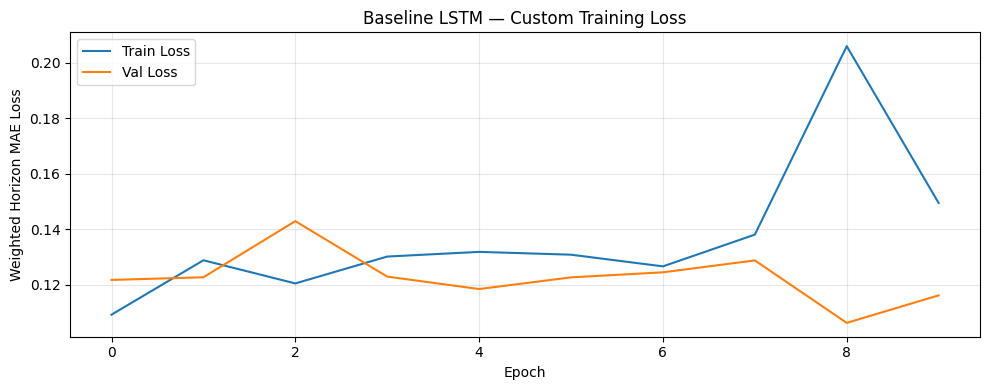

In [21]:
# Plot training history baseline LSTM custom
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(history_baseline_custom['loss'],     label='Train Loss')
ax.plot(history_baseline_custom['val_loss'], label='Val Loss')
ax.set_title('Baseline LSTM — Custom Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted Horizon MAE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12.2 Custom Training — Seq2Seq Multivariate (Model Subclassing) dengan Teacher Forcing

In [22]:
optimizer_seq2seq  = tf.keras.optimizers.Adam(learning_rate=1e-3)
early_stop_seq2seq = CustomEarlyStopping(patience=15, min_delta=1e-5,
                                         restore_best_weights=True)
reduce_lr_seq2seq  = CustomReduceLROnPlateau(optimizer_seq2seq,
                                             patience=5, factor=0.5, min_lr=1e-7)

print("Training Seq2Seq Multivariate dengan Custom Training Loop (Teacher Forcing)...")
print("=" * 70)
history_seq2seq = custom_training_loop_seq2seq(
    model          = seq2seq_model,
    train_dataset  = train_ds_multi,
    val_dataset    = val_ds_multi,
    epochs         = 10,
    loss_fn        = weighted_horizon_mae_loss,
    optimizer      = optimizer_seq2seq,
    early_stopping = early_stop_seq2seq,
    reduce_lr      = reduce_lr_seq2seq,
)

Training Seq2Seq Multivariate dengan Custom Training Loop (Teacher Forcing)...
Epoch   1/10 — loss: 0.254316 — val_loss: 0.158349 — lr: 1.00e-03
Epoch   2/10 — loss: 0.117351 — val_loss: 0.222493 — lr: 1.00e-03
Epoch   3/10 — loss: 0.124447 — val_loss: 0.181611 — lr: 1.00e-03
Epoch   4/10 — loss: 0.130695 — val_loss: 0.119227 — lr: 1.00e-03
Epoch   5/10 — loss: 0.136664 — val_loss: 0.112089 — lr: 1.00e-03
Epoch   6/10 — loss: 0.165176 — val_loss: 0.108567 — lr: 1.00e-03
Epoch   7/10 — loss: 0.159724 — val_loss: 0.109816 — lr: 1.00e-03
Epoch   8/10 — loss: 0.168516 — val_loss: 0.111666 — lr: 1.00e-03
Epoch   9/10 — loss: 0.158376 — val_loss: 0.110669 — lr: 1.00e-03
Epoch  10/10 — loss: 0.158039 — val_loss: 0.106233 — lr: 1.00e-03


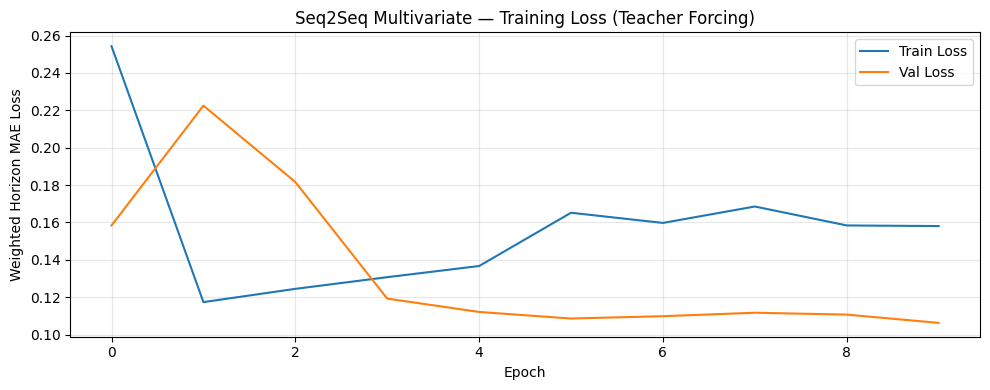

✓ Model Seq2Seq Multivariate disimpan: seq2seq_multivariate_model.keras


In [23]:
# Plot training history Seq2Seq
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(history_seq2seq['loss'],     label='Train Loss')
ax.plot(history_seq2seq['val_loss'], label='Val Loss')
ax.set_title('Seq2Seq Multivariate — Training Loss (Teacher Forcing)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted Horizon MAE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simpan Seq2Seq model
seq2seq_model.save('seq2seq_multivariate_model.keras')
print("✓ Model Seq2Seq Multivariate disimpan: seq2seq_multivariate_model.keras")

## 13. Evaluasi dan Inference pada Data Test



In [24]:
# ============================================================
# Evaluasi Seq2Seq Attention (Functional API) pada test data
# ============================================================
test_loss, test_mae = model_attention.evaluate(test_ds_multi, verbose=0)
print(f"Seq2Seq Attention (Functional) — Test Loss (MSE): {test_loss:.6f}")
print(f"Seq2Seq Attention (Functional) — Test MAE: {test_mae:.6f}")

# Prediksi dengan model attention (Functional API)
attention_preds_list = []
attention_targets_list = []

for (enc_in, dec_in), dec_target in test_ds_multi:
    preds = model_attention.predict([enc_in, dec_in], verbose=0)
    attention_preds_list.append(preds)
    attention_targets_list.append(dec_target.numpy())

attention_preds_scaled = np.concatenate(attention_preds_list, axis=0)    # (N, 24, 1)
attention_targets_scaled = np.concatenate(attention_targets_list, axis=0) # (N, 24, 1)

Seq2Seq Attention (Functional) — Test Loss (MSE): 0.002874
Seq2Seq Attention (Functional) — Test MAE: 0.051706


In [25]:
# ============================================================
# Evaluasi Baseline LSTM & Seq2Seq Subclassing pada test data
# ============================================================

# Baseline LSTM — direct multi-step
baseline_preds_list = []
baseline_targets_list = []
for x_batch, y_batch in test_ds_baseline:
    preds = baseline_lstm_v2(x_batch, training=False).numpy()
    baseline_preds_list.append(preds)
    baseline_targets_list.append(y_batch.numpy())

baseline_preds_scaled = np.concatenate(baseline_preds_list, axis=0)     # (N, 24)
baseline_targets_scaled = np.concatenate(baseline_targets_list, axis=0) # (N, 24)

# Seq2Seq Subclassing — autoregressive (training=False → no teacher forcing)
seq2seq_preds_list = []
seq2seq_targets_list = []
for (enc_in, dec_in), dec_target in test_ds_multi:
    preds = seq2seq_model([enc_in, dec_in], training=False).numpy()
    seq2seq_preds_list.append(preds)
    seq2seq_targets_list.append(dec_target.numpy())

seq2seq_preds_scaled = np.concatenate(seq2seq_preds_list, axis=0)     # (N, 24, 1)
seq2seq_targets_scaled = np.concatenate(seq2seq_targets_list, axis=0) # (N, 24, 1)

# MAE sebelum inverse scale
baseline_mae_scaled  = np.mean(np.abs(baseline_targets_scaled - baseline_preds_scaled))
seq2seq_mae_scaled   = np.mean(np.abs(seq2seq_targets_scaled - seq2seq_preds_scaled))
attention_mae_scaled = np.mean(np.abs(attention_targets_scaled - attention_preds_scaled))

print("=" * 60)
print("Evaluasi pada Data Test (sebelum inverse scale):")
print("=" * 60)
print(f"Baseline LSTM MAE              : {baseline_mae_scaled:.6f}")
print(f"Seq2Seq Subclassing MAE        : {seq2seq_mae_scaled:.6f}")
print(f"Seq2Seq Attention (Func.) MAE  : {attention_mae_scaled:.6f}")
print("=" * 60)

Evaluasi pada Data Test (sebelum inverse scale):
Baseline LSTM MAE              : 0.106854
Seq2Seq Subclassing MAE        : 0.117970
Seq2Seq Attention (Func.) MAE  : 0.051706


## 14. Inverse Transform & Visualisasi Prediksi

In [26]:
def inverse_transform_price(scaled_values, scaler):
    """
    Inverse transform scaled Price values kembali ke skala asli.
    Scaler di-fit pada 3 fitur, jadi kita buat dummy array dengan 0 untuk kolom lain.
    """
    flat = scaled_values.flatten()
    dummy = np.zeros((len(flat), 3))
    dummy[:, 0] = flat  # Kolom ke-0 = Price
    inversed = scaler.inverse_transform(dummy)[:, 0]
    return inversed.reshape(scaled_values.shape)


# Inverse transform semua prediksi dan target
# Baseline: shape (N, 5)
y_test_actual_baseline    = inverse_transform_price(baseline_targets_scaled, scaler)
baseline_preds_actual     = inverse_transform_price(baseline_preds_scaled, scaler)

# Seq2Seq Subclassing: shape (N, 5, 1) → squeeze ke (N, 5)
y_test_actual_seq2seq     = inverse_transform_price(seq2seq_targets_scaled.squeeze(-1), scaler)
seq2seq_preds_actual      = inverse_transform_price(seq2seq_preds_scaled.squeeze(-1), scaler)

# Seq2Seq Attention (Functional): shape (N, 5, 1) → squeeze ke (N, 5)
y_test_actual_attention   = inverse_transform_price(attention_targets_scaled.squeeze(-1), scaler)
attention_preds_actual    = inverse_transform_price(attention_preds_scaled.squeeze(-1), scaler)

print(f"Baseline       — actual shape: {y_test_actual_baseline.shape}, preds shape: {baseline_preds_actual.shape}")
print(f"Seq2Seq Sub.   — actual shape: {y_test_actual_seq2seq.shape}, preds shape: {seq2seq_preds_actual.shape}")
print(f"Seq2Seq Attn.  — actual shape: {y_test_actual_attention.shape}, preds shape: {attention_preds_actual.shape}")

Baseline       — actual shape: (4992, 24), preds shape: (4992, 24)
Seq2Seq Sub.   — actual shape: (4992, 24), preds shape: (4992, 24)
Seq2Seq Attn.  — actual shape: (4992, 24), preds shape: (4992, 24)


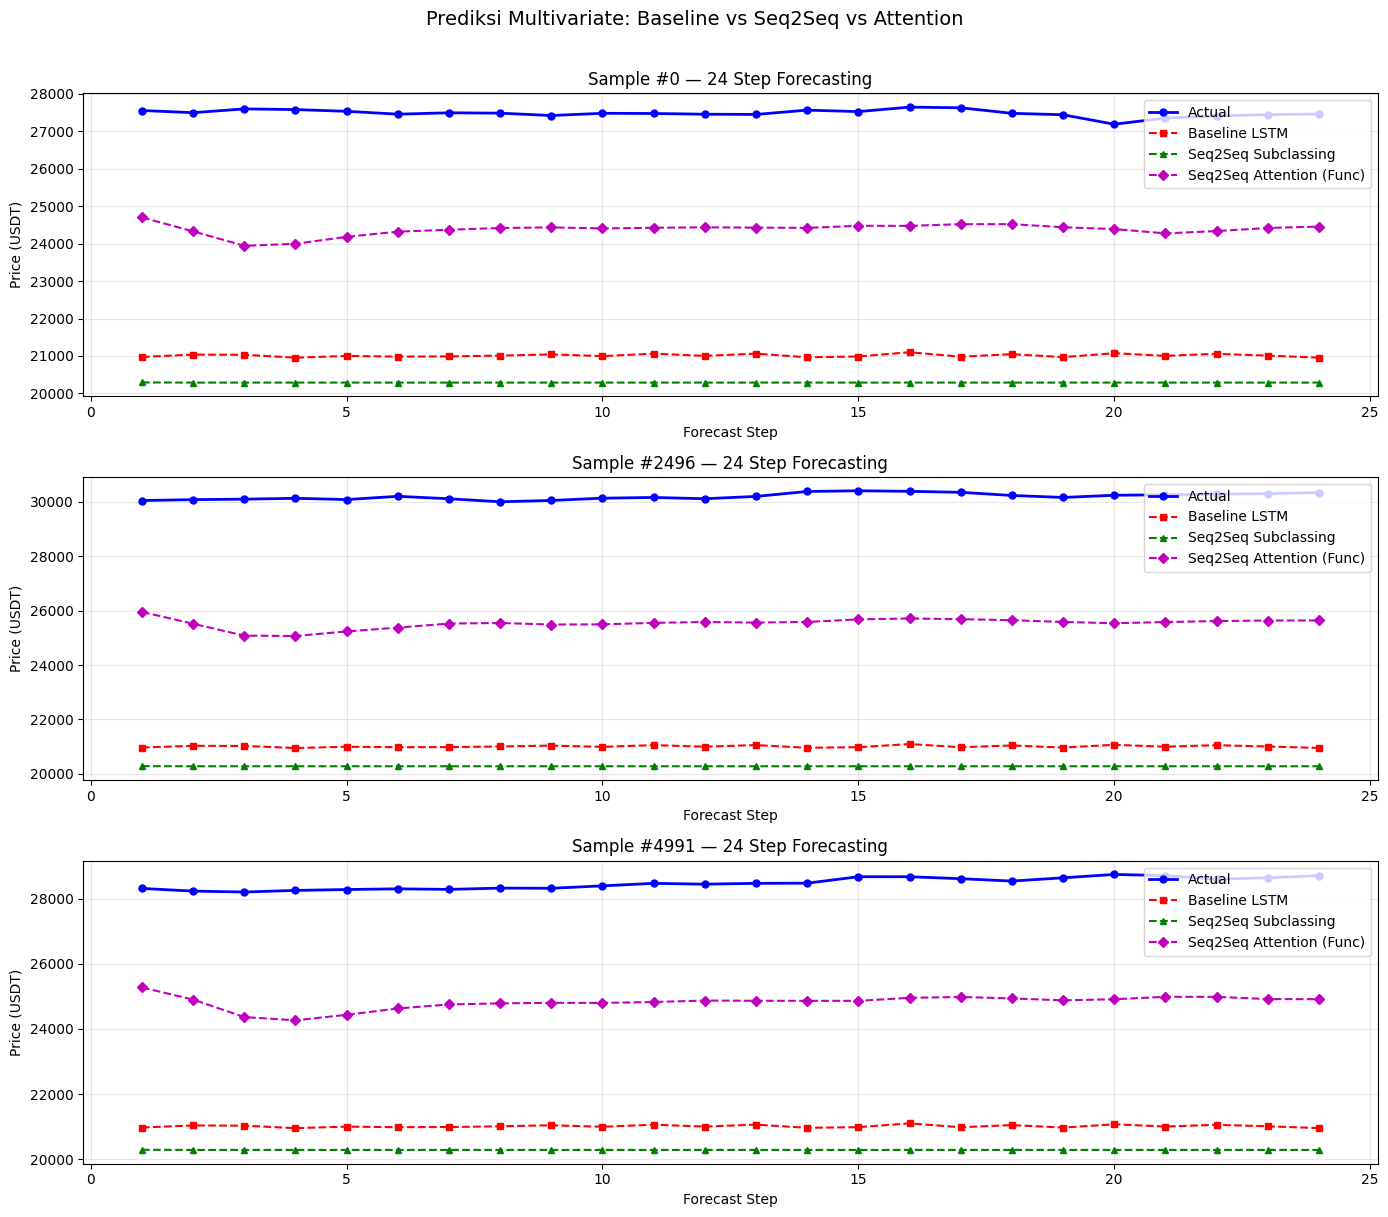

In [27]:
# Visualisasi Prediksi — 3 sampel: awal, tengah, akhir
sample_indices = [0, len(y_test_actual_attention) // 2, len(y_test_actual_attention) - 1]
steps = np.arange(1, HORIZON + 1)

fig, axes = plt.subplots(len(sample_indices), 1,
                          figsize=(14, 4 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    axes[i].plot(steps, y_test_actual_attention[idx],
                 'b-o',  label='Actual',                  markersize=5, linewidth=2)
    axes[i].plot(steps, baseline_preds_actual[idx],
                 'r--s', label='Baseline LSTM',           markersize=5)
    axes[i].plot(steps, seq2seq_preds_actual[idx],
                 'g--^', label='Seq2Seq Subclassing',     markersize=5)
    axes[i].plot(steps, attention_preds_actual[idx],
                 'm--D', label='Seq2Seq Attention (Func)', markersize=5)
    axes[i].set_title(f'Sample #{idx} — {HORIZON} Step Forecasting')
    axes[i].set_xlabel('Forecast Step')
    axes[i].set_ylabel('Price (USDT)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Prediksi Multivariate: Baseline vs Seq2Seq vs Attention', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

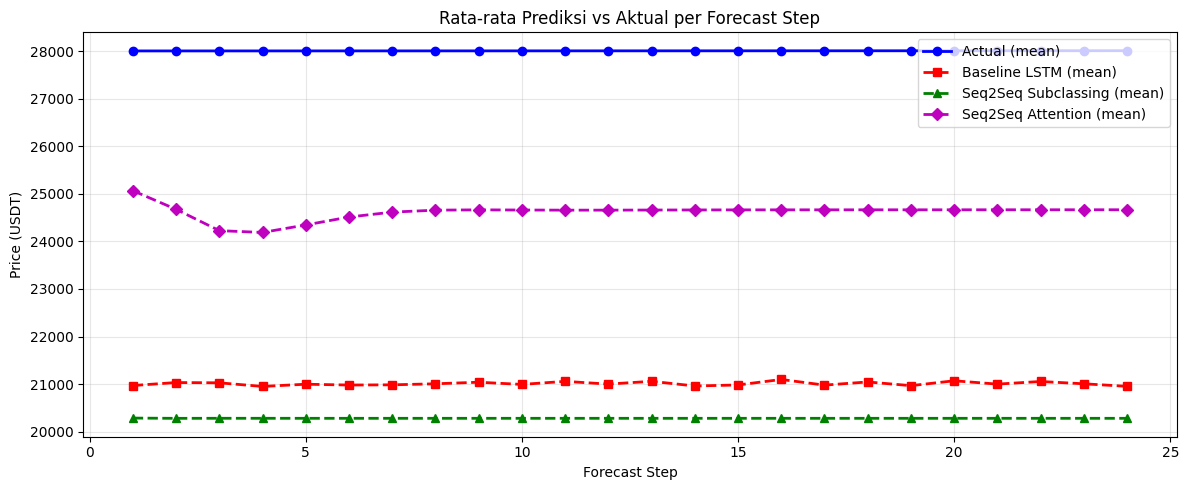

In [28]:
# Visualisasi rata-rata prediksi per forecast step
mean_actual    = y_test_actual_attention.mean(axis=0)
mean_baseline  = baseline_preds_actual.mean(axis=0)
mean_seq2seq   = seq2seq_preds_actual.mean(axis=0)
mean_attention = attention_preds_actual.mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(steps, mean_actual,    'b-o',  label='Actual (mean)',               markersize=6, linewidth=2)
plt.plot(steps, mean_baseline,  'r--s', label='Baseline LSTM (mean)',        markersize=6, linewidth=2)
plt.plot(steps, mean_seq2seq,   'g--^', label='Seq2Seq Subclassing (mean)',  markersize=6, linewidth=2)
plt.plot(steps, mean_attention, 'm--D', label='Seq2Seq Attention (mean)',    markersize=6, linewidth=2)
plt.title('Rata-rata Prediksi vs Aktual per Forecast Step')
plt.xlabel('Forecast Step')
plt.ylabel('Price (USDT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 14.1 Tabel Perbandingan Aktual vs Prediksi

In [29]:
# Tabel perbandingan — Sampel pertama
sample_idx = 0

comparison_all = pd.DataFrame({
    'Step'                          : np.arange(1, HORIZON + 1),
    'Actual (USDT)'                 : y_test_actual_attention[sample_idx].round(2),
    'Baseline (USDT)'               : baseline_preds_actual[sample_idx].round(2),
    'Seq2Seq Sub. (USDT)'           : seq2seq_preds_actual[sample_idx].round(2),
    'Seq2Seq Attn. (USDT)'          : attention_preds_actual[sample_idx].round(2),
    'Selisih Baseline'              : np.abs(
        y_test_actual_attention[sample_idx] - baseline_preds_actual[sample_idx]
    ).round(2),
    'Selisih Seq2Seq Sub.'          : np.abs(
        y_test_actual_attention[sample_idx] - seq2seq_preds_actual[sample_idx]
    ).round(2),
    'Selisih Seq2Seq Attn.'         : np.abs(
        y_test_actual_attention[sample_idx] - attention_preds_actual[sample_idx]
    ).round(2),
})

print(f"Tabel Perbandingan Semua Model (Sample #{sample_idx})")
comparison_all

Tabel Perbandingan Semua Model (Sample #0)


,Step,Actual (USDT),Baseline (USDT),Seq2Seq Sub. (USDT),Seq2Seq Attn. (USDT),Selisih Baseline,Selisih Seq2Seq Sub.,Selisih Seq2Seq Attn.
0,1,27556.35,20973.42,20293.38,24700.16,6582.93,7262.97,2856.19
1,2,27498.54,21036.48,20287.90,24327.87,6462.06,7210.64,3170.67
2,3,27599.66,21031.01,20289.09,23942.56,6568.65,7310.56,3657.10
3,4,27581.65,20954.10,20288.80,23996.03,6627.55,7292.85,3585.62
4,5,27535.25,21000.16,20288.52,24181.33,6535.09,7246.73,3353.92
5,6,27458.73,20982.67,20288.43,24320.66,6476.06,7170.30,3138.07
6,7,27495.66,20987.89,20288.49,24371.09,6507.77,7207.17,3124.57
7,8,27485.36,21009.18,20288.53,24417.81,6476.18,7196.83,3067.55
8,9,27422.56,21041.61,20288.53,24434.75,6380.95,7134.03,2987.81
9,10,27481.96,20996.39,20288.53,24406.56,6485.57,7193.43,3075.40


## 15. Error Metrics — MAE & RMSE

In [30]:
# Hitung MAE dan RMSE pada skala asli (USDT)
def calc_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def calc_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))


baseline_mae_actual  = calc_mae(y_test_actual_baseline, baseline_preds_actual)
baseline_rmse_actual = calc_rmse(y_test_actual_baseline, baseline_preds_actual)

seq2seq_mae_actual   = calc_mae(y_test_actual_seq2seq, seq2seq_preds_actual)
seq2seq_rmse_actual  = calc_rmse(y_test_actual_seq2seq, seq2seq_preds_actual)

attention_mae_actual  = calc_mae(y_test_actual_attention, attention_preds_actual)
attention_rmse_actual = calc_rmse(y_test_actual_attention, attention_preds_actual)

print("=" * 65)
print("EVALUASI METRIK PADA DATA TEST (skala asli — USDT)")
print("=" * 65)
print(f"{'Model':<35} {'MAE (USDT)':>12} {'RMSE (USDT)':>12}")
print("-" * 65)
print(f"{'Baseline LSTM':<35} {baseline_mae_actual:>12,.2f} {baseline_rmse_actual:>12,.2f}")
print(f"{'Seq2Seq Subclassing':<35} {seq2seq_mae_actual:>12,.2f} {seq2seq_rmse_actual:>12,.2f}")
print(f"{'Seq2Seq Attention (Functional)':<35} {attention_mae_actual:>12,.2f} {attention_rmse_actual:>12,.2f}")
print("=" * 65)

print("\n" + "=" * 65)
print("EVALUASI METRIK PADA DATA TEST (sebelum inverse scale)")
print("=" * 65)
print(f"{'Model':<35} {'MAE (scaled)':>12}")
print("-" * 65)
print(f"{'Baseline LSTM':<35} {baseline_mae_scaled:>12.6f}")
print(f"{'Seq2Seq Subclassing':<35} {seq2seq_mae_scaled:>12.6f}")
print(f"{'Seq2Seq Attention (Functional)':<35} {attention_mae_scaled:>12.6f}")
print("=" * 65)

EVALUASI METRIK PADA DATA TEST (skala asli — USDT)
Model                                 MAE (USDT)  RMSE (USDT)
-----------------------------------------------------------------
Baseline LSTM                           6,994.83     7,171.29
Seq2Seq Subclassing                     7,722.50     7,882.67
Seq2Seq Attention (Functional)          3,384.76     3,509.21

EVALUASI METRIK PADA DATA TEST (sebelum inverse scale)
Model                               MAE (scaled)
-----------------------------------------------------------------
Baseline LSTM                           0.106854
Seq2Seq Subclassing                     0.117970
Seq2Seq Attention (Functional)          0.051706
